# Visualization Notebook: insert the rl_simulation run you want to visualize in directory

In [122]:
directory = "results\ppo_test_8env"


In [123]:
import os
import pandas as pd

# Create a dictionary to store DataFrames, 
# each env result will be loaded in a different df with key env_{n}
dataframes = {}

# Loop through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith(".csv"):
        base = os.path.splitext(filename)[0]
        path = os.path.join(directory, filename)
        key = base.split("rl_results_")[-1]   # Keep only the env_n part
        dataframes[key] = pd.read_csv(path)

In [124]:
df1 = dataframes["env_1"]
df1.head(5)

,total_energy_consumption,ensemble_size,input_file_length,image_height,image_width,ensemble_accuracy,ensemble_confidence,ensemble_avg_response_time,ensemble_max_response_time,ensemble_contribution,reward,action,distribution_weights,models
0,0.003432,1,14,224,224,0.76,0.590230,0.048990,0.078428,0.660508,-1.4,6,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",['MobileNetV2']
1,0.003432,1,15,224,224,0.83,0.672587,0.047851,0.097656,0.719822,-0.7,6,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",['MobileNetV2']
2,0.003432,1,14,224,224,0.79,0.665426,0.045903,0.085115,0.741018,-1.1,6,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",['MobileNetV2']
3,0.003432,1,15,224,224,0.73,0.598959,0.048005,0.149042,0.675717,-1.7,6,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",['MobileNetV2']
4,0.003432,1,13,224,224,0.79,0.638124,0.049208,0.159034,0.683445,-1.1,10,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",['MobileNetV2']


### Define functions

In [125]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_reward(df, reward_column="reward", action_column="action", max_steps=None, window_size=256):
    if reward_column not in df.columns or action_column not in df.columns:
        raise ValueError("Missing required columns.")

    if max_steps is not None:
        df = df.iloc[:max_steps]

    rewards = df[reward_column]
    actions = df[action_column]
    moving_avg = rewards.rolling(window=window_size, min_periods=1).mean()

    def get_color(action):
        if 0 <= action <= 4:
            return 'green'
        elif 5 <= action <= 9:
            return 'red'
        elif action == 10:
            return 'blue'
        return 'gray'

    colors = [get_color(a) for a in actions]

    plt.figure(figsize=(12, 6))
    plt.plot(range(len(rewards)), rewards, linestyle='-', color='black', alpha=0.3, label="Reward Trend")
    plt.plot(range(len(moving_avg)), moving_avg, linestyle='-', color='orange', linewidth=2, label=f"Moving Avg (Window={window_size})")
    plt.scatter(range(len(rewards)), rewards, c=colors, alpha=0.7, label="Reward Values")

    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='w', markersize=10, markerfacecolor=color, label=label)
        for color, label in zip(["green", "red", "blue"], ["Add Model (0-4)", "Remove Model (5-9)", "Keep Ensemble (10)"])
    ]
    plt.legend(handles=legend_handles + [plt.Line2D([0], [0], color='orange', linewidth=2, label="Moving Average")],
               title="Actions", loc="upper left")

    plt.title(f'{reward_column} Plot with Moving Average')
    plt.xlabel('Step')
    plt.ylabel('Value')
    plt.grid(True)
    plt.show()


In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

def plot_reward_chunks(df, reward_column="reward", action_column="action", chunk_size=128):
    if reward_column not in df.columns or action_column not in df.columns:
        raise ValueError("Missing required columns.")

    chunked = df.groupby(df.index // chunk_size).mean()
    avg_rewards = chunked[reward_column]
    avg_actions = chunked[action_column]

    def get_color(action):
        if 0 <= action <= 4:
            return 'green'
        elif 5 <= action <= 9:
            return 'red'
        elif action == 10:
            return 'blue'
        return 'gray'

    colors = [get_color(a) for a in avg_actions]

    X = sm.add_constant(np.arange(len(avg_rewards)))
    y = avg_rewards.values
    model = sm.OLS(y, X).fit()
    print(model.summary())
    trend = model.predict(X)

    plt.figure(figsize=(12, 6))
    plt.plot(X[:, 1], avg_rewards, color='orange', linewidth=2, label=f"Average Reward per {chunk_size} Steps")
    plt.scatter(X[:, 1], avg_rewards, c=colors, alpha=0.7)
    plt.plot(X[:, 1], trend, linestyle='--', color='blue', linewidth=2)

    legend = [
        plt.Line2D([0], [0], marker='o', color='w', markersize=10, markerfacecolor=c, label=l)
        for c, l in zip(["green", "red", "blue"], ["Add Model (0-4)", "Remove Model (5-9)", "Keep Ensemble (10)"])
    ]
    legend += [
        plt.Line2D([0], [0], color='orange', linewidth=2, label="Average Reward per Chunk"),
        plt.Line2D([0], [0], color='blue', linestyle='--', linewidth=2, label="Linear Regression Trend Line")
    ]
    plt.legend(handles=legend, title="Actions", loc="upper left")
    plt.title(f'Average {reward_column.capitalize()} per {chunk_size} Steps with Regression Trend Line')
    plt.xlabel('Chunk Index')
    plt.ylabel('Average Reward')
    plt.grid(True)
    plt.show()


In [127]:
def plot_reward_all(dataframes, reward_column="reward", window_size=256):
    plt.figure(figsize=(14, 7))

    for key, df in dataframes.items():
        if reward_column not in df.columns:
            continue
        rewards = df[reward_column]
        moving_avg = rewards.rolling(window=window_size, min_periods=1).mean()
        plt.plot(moving_avg, label=key)

    plt.title(f"Moving Average of {reward_column} (Window={window_size})")
    plt.xlabel("Step")
    plt.ylabel("Moving Average")
    plt.legend(title="Environment")
    plt.grid(True)
    plt.show()


## Reading the data

### Reward for one enviroment

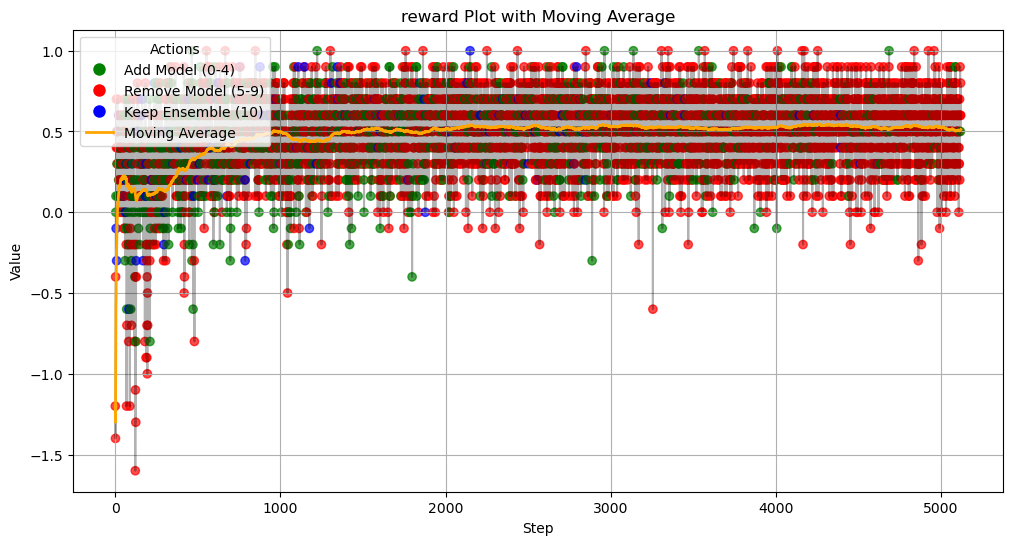

In [135]:
plot_reward(df = dataframes["env_2"], window_size=256)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     27.46
Date:                Fri, 04 Apr 2025   Prob (F-statistic):           6.26e-06
Time:                        13:17:49   Log-Likelihood:                 43.930
No. Observations:                  40   AIC:                            -83.86
Df Residuals:                      38   BIC:                            -80.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3594      0.026     13.986      0.0

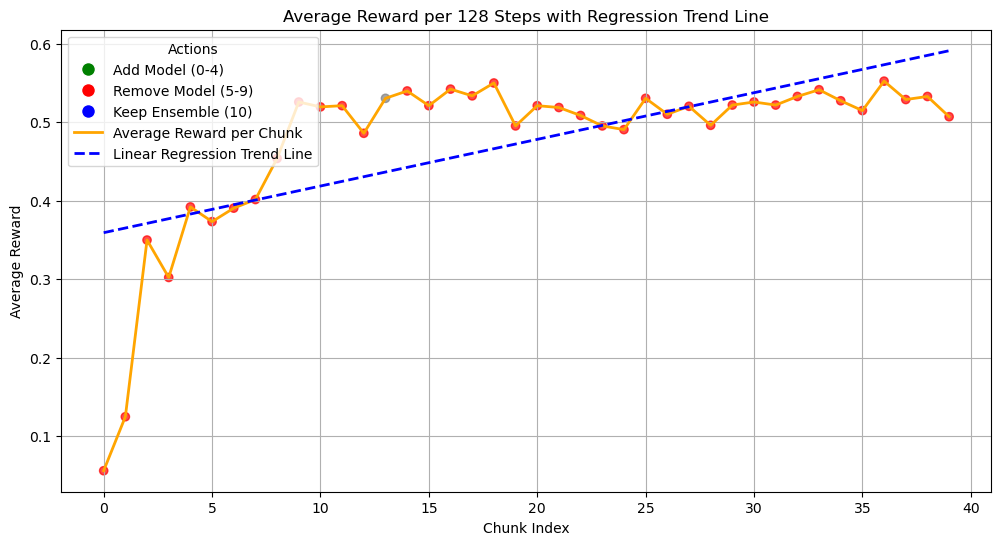

In [129]:
plot_reward_chunks(df = dataframes["env_1"], chunk_size=128)


### Reward for all enviroments

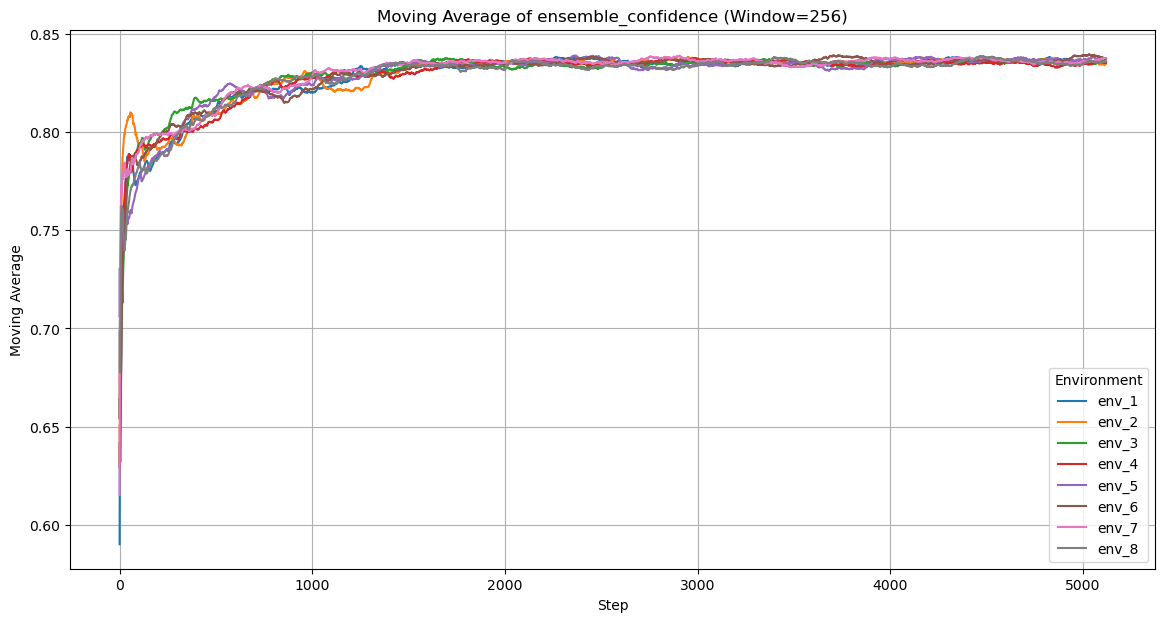

In [136]:
plot_reward_all(dataframes, "ensemble_confidence",window_size=256)

### Distance from the ideal ensemble

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

def plot_ensemble_distance_all(dataframes, column_name, ideal_ensemble, window_size=256):
    ideal_set = set(ideal_ensemble)
    plt.figure(figsize=(14, 7))

    for key, df in dataframes.items():
        if column_name not in df.columns:
            continue

        distances = []
        for models in df[column_name]:
            actual_set = set(ast.literal_eval(models))
            distance = len(actual_set - ideal_set) + len(ideal_set - actual_set)
            distances.append(distance)

        rolling = pd.Series(distances).rolling(window=window_size, min_periods=1).mean()
        plt.plot(rolling, label=key)

    plt.title(f"Ensemble Distance Rolling Average (Window={window_size})")
    plt.xlabel("Step")
    plt.ylabel("Distance")
    plt.legend(title="Environment")
    plt.grid(True)
    plt.show()


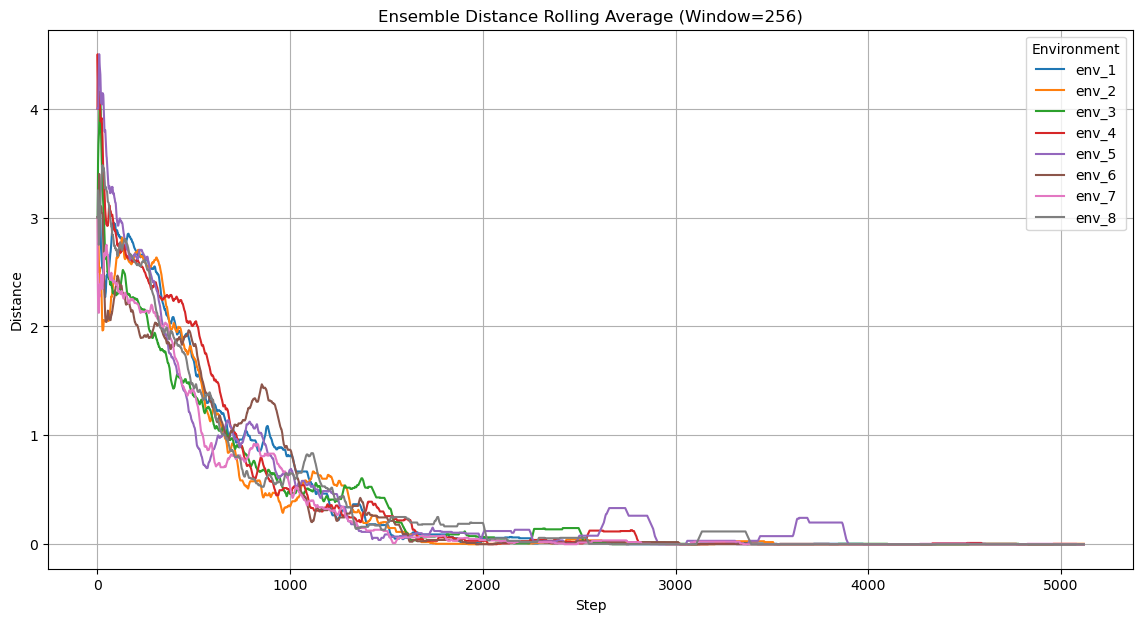

In [137]:
plot_ensemble_distance_all(dataframes, "models", ['EfficientNetV2S', 'NASNetLarge'], window_size=256)


### Area Under The Curve AUC

In [133]:
import numpy as np
import matplotlib.pyplot as plt

def plot_auc_all(dataframes, reward_column="reward", window_size=256, scale=1.0, min_y=None, max_y=None):
    plt.figure(figsize=(14, 7))
    moving_avgs = []
    max_len = 0

    for key, df in dataframes.items():
        if reward_column not in df.columns:
            continue

        rewards = df[reward_column]
        ma = rewards.rolling(window=window_size, min_periods=1).mean()
        moving_avgs.append(ma)
        max_len = max(max_len, len(ma))
        x = np.arange(len(ma))
        plt.plot(x, ma, alpha=0.3, label=key)

    padded = [ma.reindex(range(max_len), fill_value=np.nan).values for ma in moving_avgs]
    avg_curve = np.nanmean(padded, axis=0)
    avg_curve *= scale

    x = np.arange(len(avg_curve))
    plt.plot(x, avg_curve, color='black', linewidth=2.5, label=f"Average Trend (×{scale})")

    # Fill positive (blue) and negative (red) regions separately
    plt.fill_between(x, avg_curve, where=avg_curve >= 0, interpolate=True, color='blue', alpha=0.3, label="Positive Area")
    plt.fill_between(x, avg_curve, where=avg_curve < 0, interpolate=True, color='red', alpha=0.3, label="Negative Area")

    auc = np.trapz(avg_curve[np.isfinite(avg_curve)])
    print(f"Scaled AUC of averaged moving curves: {auc:.2f}")
    print("Negative values decrease the area")
    print("A higher area means a faster convergence")

    plt.title(f"Average Moving Average (Window={window_size}) with AUC={auc:.2f}")
    plt.xlabel("Step")
    plt.ylabel("Moving Average")
    plt.legend(title="Environment + Avg")
    plt.grid(True)

    # Apply y-axis limits if provided
    if min_y is not None or max_y is not None:
        plt.ylim(bottom=min_y, top=max_y)

    plt.show()


Scaled AUC of averaged moving curves: 2409.87
Negative values decrease the area
A higher area means a faster convergence


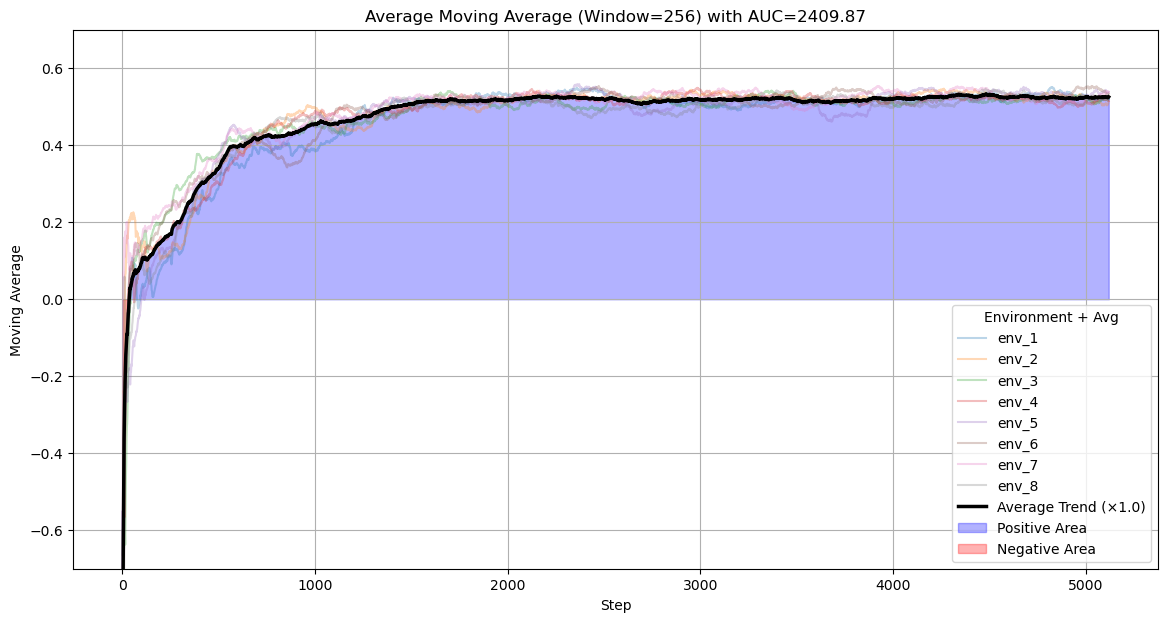

In [134]:
plot_auc_all(dataframes, "reward",window_size=256, min_y= -0.7, max_y= 0.7)